# Market Risk Modeling and Backtesting Framework

This project develops a portfolio risk model using Python. 
The objective is to estimate and evaluate market risk using 
Value-at-Risk (VaR) and backtesting techniques.

The analysis includes:
- Portfolio construction
- Risk estimation using multiple models
- Backtesting and validation of model performance

This project reflects practical approaches used in financial institutions.

# 1. Data Collection and Portfolio Construction

In this section, we load financial data and construct a diversified portfolio.

We use multiple assets to simulate a realistic investment scenario. 
The data consists of daily price observations, which are transformed 
into returns for further analysis.

A portfolio is created by assigning weights to each asset, allowing us 
to study the aggregated risk behavior rather than individual securities.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("financial_data.csv", index_col="Date", parse_dates=True)

data.head()

,SPY,QQQ,IWM,EFA
Date,,,,
2018-01-01,251.244669,152.738733,120.229072,70.331818
2018-01-02,250.985103,152.597571,120.752297,70.403704
2018-01-03,252.594765,152.682277,120.787910,70.443003
2018-01-04,256.326131,154.099618,117.988983,68.783209
2018-01-05,255.829411,154.602139,118.229131,69.314725


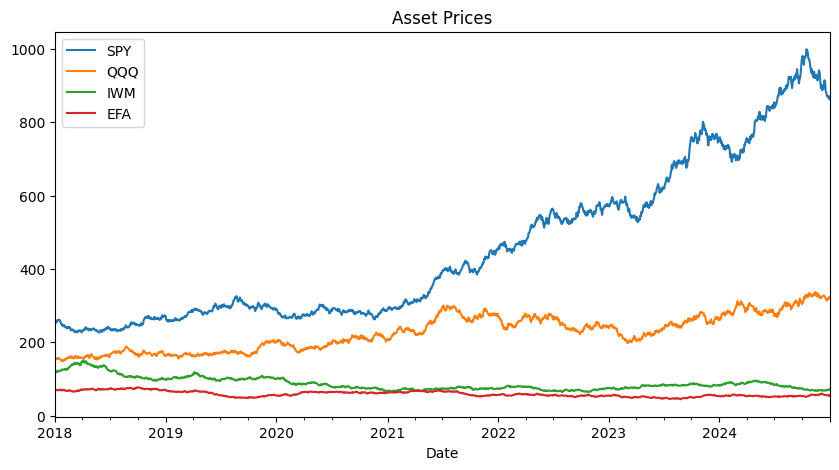

In [2]:
data.plot(figsize=(10,5))
plt.title("Asset Prices")
plt.show()

## Log Returns Calculation

We compute log returns using the formula:

r_t = log(P_t / P_{t-1})

Log returns are widely used in financial modeling because:
- They are additive over time
- They simplify statistical analysis
- They are standard in risk management models

In [3]:
returns = np.log(data / data.shift(1))
returns = returns.dropna()

returns.head()

,SPY,QQQ,IWM,EFA
Date,,,,
2018-01-02,-0.001034,-0.000925,0.004342,0.001022
2018-01-03,0.006393,0.000555,0.000295,0.000558
2018-01-04,0.014664,0.009240,-0.023445,-0.023844
2018-01-05,-0.001940,0.003256,0.002033,0.007698
2018-01-08,-0.001940,0.012326,0.025301,0.001540


In [4]:
weights = np.array([0.25, 0.25, 0.25, 0.25])

portfolio_returns = returns.dot(weights)

portfolio_returns.head()

Date
2018-01-02    0.000851
2018-01-03    0.001950
2018-01-04   -0.005846
2018-01-05    0.002762
2018-01-08    0.009307
dtype: float64

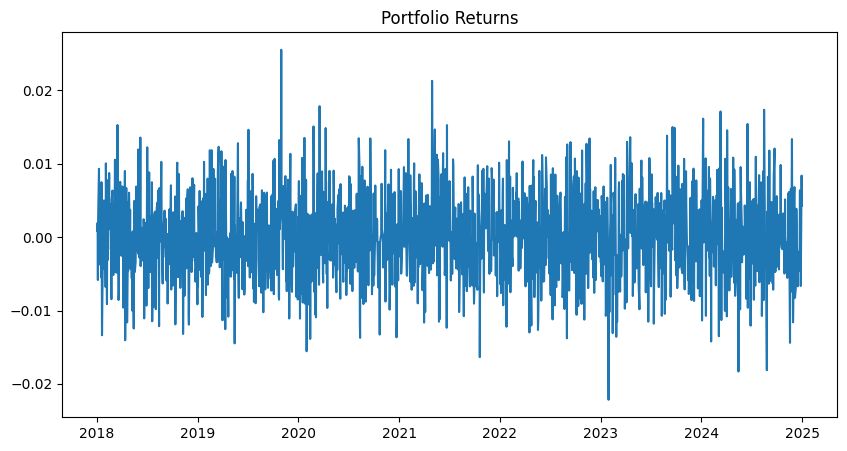

In [5]:
plt.figure(figsize=(10,5))
plt.plot(portfolio_returns)
plt.title("Portfolio Returns")
plt.show()

# 2. Value-at-Risk (VaR)

Value-at-Risk (VaR) is a widely used measure of financial risk. 
It estimates the maximum expected loss over a given time horizon 
at a specified confidence level.

For example:
- A 95% VaR indicates that losses will exceed this value only 5% of the time
- A 99% VaR captures more extreme risk scenarios

VaR provides a simple and intuitive way to quantify risk exposure.

In [6]:
from scipy.stats import norm
alpha_95 = 0.95
alpha_99 = 0.99

## Historical VaR

Historical VaR is calculated using past return data without assuming 
any specific distribution.

This method directly uses empirical quantiles of the return distribution, 
making it flexible and easy to implement. However, it relies heavily on 
historical data and may not fully capture future risk.

In [7]:
hist_var_95 = -np.quantile(portfolio_returns, 1 - alpha_95)
hist_var_99 = -np.quantile(portfolio_returns, 1 - alpha_99)

print("Historical VaR 95%:", hist_var_95)
print("Historical VaR 99%:", hist_var_99)

Historical VaR 95%: 0.009069097585457613
Historical VaR 99%: 0.013052238724690076


## Parametric VaR

Parametric VaR assumes that returns follow a normal distribution. 
It estimates risk using the mean and standard deviation of returns.

This approach is computationally efficient, but it may underestimate 
extreme losses if the true distribution exhibits heavy tails.

In [8]:
mu = portfolio_returns.mean()
sigma = portfolio_returns.std()

z_95 = norm.ppf(1 - alpha_95)
z_99 = norm.ppf(1 - alpha_99)

param_var_95 = -(mu + z_95 * sigma)
param_var_99 = -(mu + z_99 * sigma)

print("Parametric VaR 95%:", param_var_95)
print("Parametric VaR 99%:", param_var_99)

Parametric VaR 95%: 0.009154809511474892
Parametric VaR 99%: 0.01301686013374675


In [9]:
var_table = pd.DataFrame({
    "Model": ["Historical VaR", "Parametric VaR"],
    "95%": [hist_var_95, param_var_95],
    "99%": [hist_var_99, param_var_99]
})

print(var_table)

            Model       95%       99%
0  Historical VaR  0.009069  0.013052
1  Parametric VaR  0.009155  0.013017


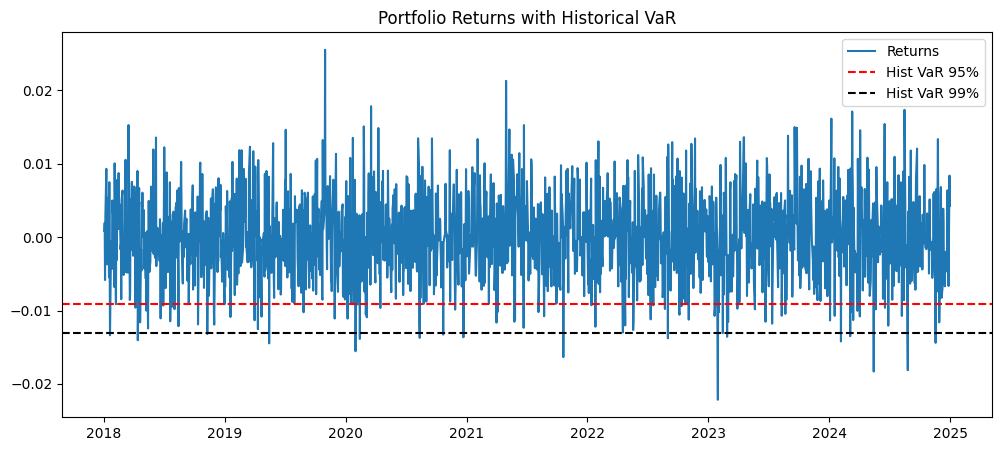

In [10]:
plt.figure(figsize=(12,5))
plt.plot(portfolio_returns, label="Returns")
plt.axhline(-hist_var_95, color='red', linestyle='--', label='Hist VaR 95%')
plt.axhline(-hist_var_99, color='black', linestyle='--', label='Hist VaR 99%')
plt.title("Portfolio Returns with Historical VaR")
plt.legend()
plt.show()

# 3. Backtesting

Backtesting is used to evaluate the performance of risk models.

We compare predicted Value-at-Risk (VaR) levels with actual portfolio returns. 
A violation occurs when the realized loss exceeds the VaR estimate.

For a well-calibrated model:
- 95% VaR should have ~5% violations
- 99% VaR should have ~1% violations

In [11]:
violations_95 = (portfolio_returns < -hist_var_95)
violations_99 = (portfolio_returns < -hist_var_99)

# count
num_violations_95 = violations_95.sum()
num_violations_99 = violations_99.sum()

total_days = len(portfolio_returns)

print("Total days:", total_days)
print("95% violations:", num_violations_95)
print("99% violations:", num_violations_99)

print("95% violation rate:", num_violations_95 / total_days)
print("99% violation rate:", num_violations_99 / total_days)

Total days: 1826
95% violations: 92
99% violations: 19
95% violation rate: 0.050383351588170866
99% violation rate: 0.0104052573932092


## Violation Analysis

The violation rate is compared to the expected theoretical rate.

If the observed violation frequency deviates significantly from the expected level, 
the VaR model may be poorly calibrated.

A higher-than-expected violation rate indicates underestimation of risk, 
while a lower rate may indicate overestimation.

## Kupiec Test

The Kupiec test evaluates whether the observed number of VaR violations 
is consistent with the expected frequency.

It is widely used in financial institutions to validate risk models.

In [12]:
import numpy as np

def kupiec_test(violations, total, alpha):
    p = 1 - alpha
    phat = violations / total
    
    LR = -2 * (
        (total - violations) * np.log((1 - p) / (1 - phat)) +
        violations * np.log(p / phat)
    )
    
    return LR

lr_95 = kupiec_test(num_violations_95, total_days, 0.95)
lr_99 = kupiec_test(num_violations_99, total_days, 0.99)

print("Kupiec statistic (95%):", lr_95)
print("Kupiec statistic (99%):", lr_99)

Kupiec statistic (95%): 0.005635766047123347
Kupiec statistic (99%): 0.029894912995049427


## Interpretation of Kupiec Test

The Kupiec test statistic evaluates whether the model produces the correct 
number of violations.

- A low value suggests the model is well calibrated
- A high value indicates that the model may not be reliable

This provides a statistical validation of the VaR model.

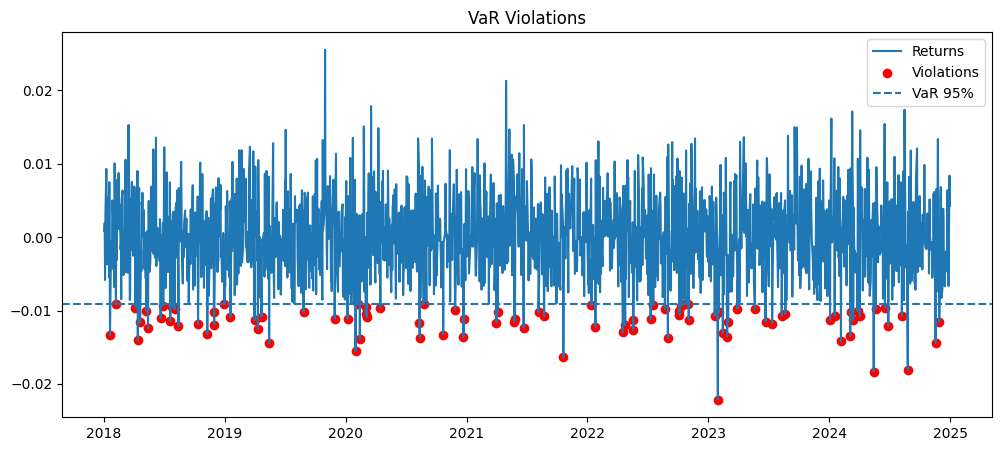

In [13]:
plt.figure(figsize=(12,5))
plt.plot(portfolio_returns, label="Returns")

violations = portfolio_returns[portfolio_returns < -hist_var_95]

plt.scatter(violations.index, violations, color='red', label='Violations')

plt.axhline(-hist_var_95, linestyle='--', label='VaR 95%')

plt.title("VaR Violations")
plt.legend()
plt.show()

# 4. Expected Shortfall (ES)

While Value-at-Risk estimates a loss threshold, it does not provide 
information about the magnitude of losses beyond that threshold.

Expected Shortfall (ES), also known as Conditional VaR, measures the 
average loss given that the VaR level has been exceeded.

It provides a more comprehensive view of tail risk and is widely used 
in modern risk management frameworks.

In [14]:
# ES at 95%
es_95 = -portfolio_returns[portfolio_returns < -hist_var_95].mean()

# ES at 99%
es_99 = -portfolio_returns[portfolio_returns < -hist_var_99].mean()

print("Expected Shortfall 95%:", es_95)
print("Expected Shortfall 99%:", es_99)

Expected Shortfall 95%: 0.011573672471738839
Expected Shortfall 99%: 0.014879775246428426


## Interpretation of Expected Shortfall

Expected Shortfall is always greater than Value-at-Risk because it 
captures the severity of losses beyond the VaR threshold.

This makes ES a more conservative and informative measure of risk, 
especially during extreme market conditions.

# 5. Rolling Value-at-Risk

Risk is not constant over time. Market volatility changes, and risk 
models must adapt accordingly.

To capture this, we compute Value-at-Risk using a rolling window, 
which updates the model based on recent data.

In [17]:
window = 250  # approx 1 year

rolling_var_95 = portfolio_returns.rolling(window).quantile(0.05)

# drop NaN
rolling_var_95 = rolling_var_95.dropna()

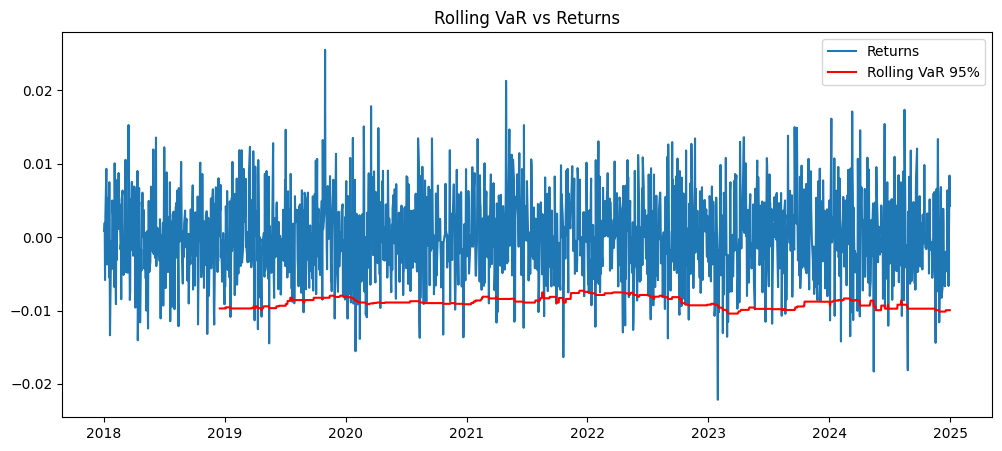

In [18]:
plt.figure(figsize=(12,5))
plt.plot(portfolio_returns, label="Returns")
plt.plot(rolling_var_95, color='red', label="Rolling VaR 95%")

plt.title("Rolling VaR vs Returns")
plt.legend()
plt.show()

## Interpretation of Rolling VaR

The rolling VaR adapts to changing market conditions by using a 
moving window of historical data.

Periods of high volatility lead to higher VaR values, while calm 
periods result in lower risk estimates.

This reflects the dynamic nature of financial markets.